In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:

def gaussian_field_1d(Pk):
    """
    Generate a 1D real Gaussian random field with input power spectrum Pk.
    """
    N = len(Pk)
    fk = np.zeros(N, dtype=complex)

    # k=0 (real only)
    fk[0] = np.sqrt(Pk[0]) * np.random.randn()

    # Nyquist (if even)
    if N % 2 == 0:
        fk[N//2] = np.sqrt(Pk[N//2]) * np.random.randn()

    # positive frequencies
    kmax = N//2 if N % 2 == 0 else (N-1)//2
    for k in range(1, kmax):
        a, b = np.random.randn(), np.random.randn()
        fk[k] = np.sqrt(Pk[k]/2) * (a + 1j*b)
        fk[-k] = fk[k].conjugate()   # Hermitian symmetry

    # inverse FFT -> real field
    return np.fft.ifft(fk).real


In [16]:
N = 2048
k = np.arange(N)+1

# Example power spectrum: P(k) ~ k^-2 (avoid k=0 divergence)
Pk = k**-2.

field = gaussian_field_1d(Pk)


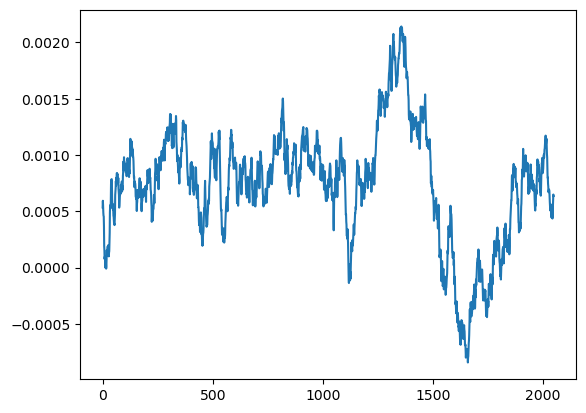

In [17]:
plt.plot(field)